# RL Group Project: Starter Notebook
## Clinical Treatment Optimisation: Sepsis ICU Management

**Master in Data Science & Advanced Analytics — Reinforcement Learning Course**

This project is structured in two stages of increasing complexity.

- In **Configuration A**, you will work with a tabular Sepsis MDP, where the state and action spaces are small enough to apply classical RL methods directly. 

- In **Configuration B**, you will move to a continuous-observation ICU environment that is clinically grounded and significantly more challenging. 

Three realistic failure modes are present in Configuration B, each reflecting a real scenario encountered in clinical AI deployments. The first is episodic observation noise, where monitoring equipment occasionally malfunctions. The second is episodic missing observations, representing situations where lab results are simply unavailable for an entire episode. The third is acute clinical events, which are sudden and irreversible patient deteriorations that occur independently of any treatment given.


---
### Group Members
Fill in before submitting:

Name of the Group: Group AB

```
Student 1: Andreea Roica
Student 2: Marisa Esteves
Student 3: Miguel Caramelo
Student 4: Oliver Kain
```


## 0. Setup & Imports


In [81]:
# Install dependencies (run once)
#!pip install icu-sepsis numpy pandas matplotlib seaborn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import warnings
import os
import sys
import random

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

os.makedirs('plots', exist_ok=True)
PLOTS_DIR = 'plots'

SEED = 42
np.random.seed(SEED)

#  Import constants and env factory from env_setup.py 
from envs.env_setup import (
    ENV_ID, N_STATES, N_ACTIONS, STATE_SURVIVED, STATE_DIED,
    GAMMA, INTENSITY, SOFA_BIAS, LAM,
    make_sepsis_env,
)

print(f'ICU-Sepsis-v2 | States: {N_STATES} | Actions: {N_ACTIONS}')
print(f'Terminal states: {STATE_SURVIVED} (survived, r=+1)  {STATE_DIED} (died, r=0)')
print('Setup complete!')


ICU-Sepsis-v2 | States: 716 | Actions: 25
Terminal states: 714 (survived, r=+1)  713 (died, r=0)
Setup complete!


In [2]:
# Configuration already loaded from env_setup.py
# env_setup.py defines: SOFA_BIAS=5.0, LAM=0.02, INTENSITY, make_sepsis_env()
print(f'Required config: sofa_bias={SOFA_BIAS}, lam={LAM}')

Required config: sofa_bias=5.0, lam=0.02


---
## 1. Explore the Environment

Before writing any algorithm, take time to understand the MDP you are working with. The insights you gain here should inform your report's Methodology section.

`ICU-Sepsis-v2` is a benchmark MDP constructed from real MIMIC-III patient data. Each episode represents the trajectory of one ICU patient. The agent observes a discrete integer state (ranging from 0 to 715) and must select one of 25 treatment actions corresponding to combinations of vasopressor and IV fluid dose levels. The reward signal is sparse: **+1 at survival, 0 at death, and 0 for all intermediate steps**, with a discount factor γ = 1.


In [3]:
#  Instantiate and inspect the raw environment 
env = make_sepsis_env()
obs, info = env.reset(seed=SEED)

print(f'Observation space : {env.observation_space} discrete integer state')
print(f'Action space      : {env.action_space}')
print(f'Initial state     : {obs}')
print()

#  Extract the full MDP model 
raw = env.unwrapped
P = raw._tx_mat    # shape (716, 25, 716) — P[s,a,s'] = P(s'|s,a)
R_sasp = raw._r_mat                    # (716, 25, 716) — R[s, a, s']
R = (P * R_sasp).sum(axis=2)          # (716, 25)      — E[r | s, a]

print(f'Transition matrix P : {P.shape}  (S × A × S\')')
print(f'Reward matrix R     : {R.shape}  (S × A)')
print(f'Reward range        : [{R.min():.3f}, {R.max():.3f}]')
print()


make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
Observation space : Discrete(716) discrete integer state
Action space      : Discrete(25)
Initial state     : 559

Transition matrix P : (716, 25, 716)  (S × A × S')
Reward matrix R     : (716, 25)  (S × A)
Reward range        : [-0.020, 0.708]



In [4]:
#  Random baseline: establish the performance floor 
def run_random_baseline(n_episodes=1000, seed=SEED):
    np.random.seed(seed)
    env_eval = make_sepsis_env()
    returns, lengths = [], []
    for _ in range(n_episodes):
        obs, _ = env_eval.reset(seed=np.random.randint(100_000))
        total_r, steps, done = 0.0, 0, False
        while not done:
            obs, r, te, tr, _ = env_eval.step(env_eval.action_space.sample())
            total_r += r; steps += 1; done = te or tr
        returns.append(total_r)
        lengths.append(steps)
    env_eval.close()
    return np.array(returns), np.array(lengths)


rand_returns, rand_lengths = run_random_baseline()
survival_rate = float(np.mean(rand_returns > 0)) * 100

print(f'Random agent ({len(rand_returns)} episodes):')
print(f'  Mean return    : {np.mean(rand_returns):.4f}')
print(f'  Survival rate  : {survival_rate:.1f}%')
print(f'  Mean ep length : {np.mean(rand_lengths):.1f} steps')
print()
print('All Config A algorithms must beat the random baseline.')


make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
Random agent (1000 episodes):
  Mean return    : 0.5820
  Survival rate  : 68.4%
  Mean ep length : 10.1 steps

All Config A algorithms must beat the random baseline.


make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02


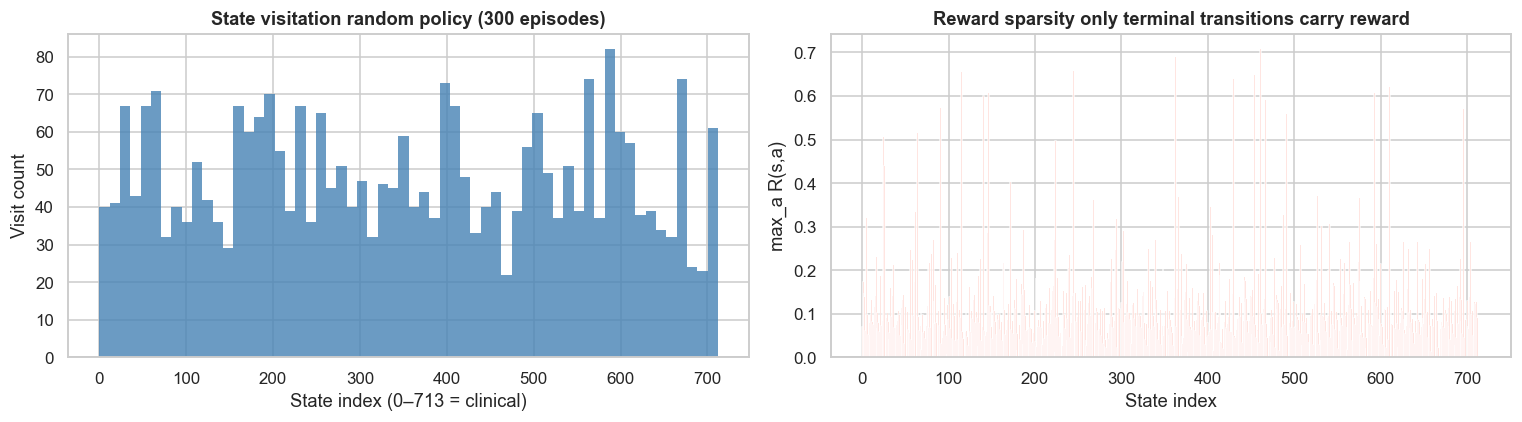

In [5]:
#  Visualise state visitation and reward structure 
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# State visitation under random policy
np.random.seed(SEED)
env_vis = make_sepsis_env()
visited = []
for _ in range(300):
    obs, _ = env_vis.reset(seed=np.random.randint(100_000))
    done = False
    while not done:
        visited.append(int(obs))
        obs, _, te, tr, _ = env_vis.step(env_vis.action_space.sample())
        done = te or tr
env_vis.close()
clinical = [s for s in visited if s not in (STATE_SURVIVED, STATE_DIED)]

axes[0].hist(clinical, bins=60, color='steelblue', edgecolor='none', alpha=0.8)
axes[0].set_xlabel('State index (0–713 = clinical)')
axes[0].set_ylabel('Visit count')
axes[0].set_title('State visitation random policy (300 episodes)', fontweight='bold')

# Max achievable reward per state (only survival-adjacent states have r > 0)
axes[1].bar(range(N_STATES), R.max(axis=1), color='tomato', width=1.0, alpha=0.8)
axes[1].set_xlabel('State index')
axes[1].set_ylabel('max_a R(s,a)')
axes[1].set_title('Reward sparsity only terminal transitions carry reward',
                  fontweight='bold')

plt.tight_layout()
plt.savefig(f'{PLOTS_DIR}/configA_env_exploration.png', bbox_inches='tight')
plt.show()


---
# Config A — Tabular Methods

With 716 discrete states and 25 actions, the Q-table has shape `(716, 25)`, totalling 17,900 entries. This size is entirely manageable in memory, which is precisely what motivates the use of tabular algorithms here.


1) Build a deterministic policy evaluation to compare algorithms:

In [60]:
def evaluate_policy(policy, n_episodes=1000, seed=SEED):
    env_eval = make_sepsis_env()

    returns = []
    lengths = []
    survivals = []

    np.random.seed(seed)

    for _ in range(n_episodes):

        obs, _ = env_eval.reset(seed=np.random.randint(100_000))

        done = False
        total_r = 0
        steps = 0

        while not done:
            action = policy[obs]

            obs, r, terminated, truncated, _ = env_eval.step(action)

            total_r += r
            steps += 1
            done = terminated or truncated

        returns.append(total_r)
        lengths.append(steps)
        survivals.append(total_r > 0)

    env_eval.close()

    return {
        "mean_return": np.mean(returns),
        "survival_rate": np.mean(survivals),
        "mean_length": np.mean(lengths),
        "returns": returns
    }

## Policy Iteration

The first algorithm we are going to use in Config A is Policy Iteration.

Policy Iteration combines policy evaluation and policy improvement into a single algorithm that is **guaranteed** to converge to the optimal policy π* in a finite number of iterations.

Therefore, policy iteration is a very strong algorithm for our problem.

In [61]:
def policy_evaluation(policy, P, R,
                      gamma=GAMMA,
                      theta=1e-8,
                      max_iterations=1000):

    V = np.zeros(N_STATES)

    for iteration in range(max_iterations):

        V_new = np.zeros_like(V)

        for s in range(N_STATES):

            a = policy[s]

            V_new[s] = np.sum(
                P[s, a] * (
                    R[s, a] + gamma * V
                )
            )

        delta = np.max(np.abs(V_new - V))

        V = V_new

        if iteration % 10 == 0:
            print(f'Policy eval iter {iteration} | delta={delta:.6f}')

        if delta < theta:
            print(f'Policy evaluation converged in {iteration} iterations')
            break

    return V

In [62]:
def policy_improvement(V, P, R, gamma=GAMMA):

    policy = np.zeros(N_STATES, dtype=int)

    for s in range(N_STATES):

        q_values = np.zeros(N_ACTIONS)

        for a in range(N_ACTIONS):

            q_values[a] = np.sum(
                P[s, a] * (
                    R[s, a] + gamma * V
                )
            )

        policy[s] = np.argmax(q_values)

    return policy

In [63]:
def policy_iteration(P, R, gamma=GAMMA):

    policy = np.zeros(N_STATES, dtype=int)

    stable = False
    iteration = 0

    iteration_history = []

    while not stable:

        iteration += 1

        V = policy_evaluation(policy, P, R, gamma)

        new_policy = policy_improvement(V, P, R, gamma)

        stable = np.array_equal(policy, new_policy)

        policy = new_policy

        iteration_history.append(iteration)

    return policy, V, iteration_history

In [64]:
pi_policy, pi_V, pi_iters = policy_iteration(P, R)

results_pi = evaluate_policy(pi_policy)

print('Policy Iteration Results')
print(f"Mean return   : {results_pi['mean_return']:.4f}")
print(f"Survival rate : {results_pi['survival_rate']:.2%}")
print(f"Mean length   : {results_pi['mean_length']:.2f}")

Policy eval iter 0 | delta=0.707581
Policy eval iter 10 | delta=0.037673
Policy eval iter 20 | delta=0.017755
Policy eval iter 30 | delta=0.007030
Policy eval iter 40 | delta=0.002797
Policy eval iter 50 | delta=0.001229
Policy eval iter 60 | delta=0.000513
Policy eval iter 70 | delta=0.000207
Policy eval iter 80 | delta=0.000081
Policy eval iter 90 | delta=0.000032
Policy eval iter 100 | delta=0.000012
Policy eval iter 110 | delta=0.000005
Policy eval iter 120 | delta=0.000002
Policy eval iter 130 | delta=0.000001
Policy eval iter 140 | delta=0.000000
Policy eval iter 150 | delta=0.000000
Policy eval iter 160 | delta=0.000000
Policy eval iter 170 | delta=0.000000
Policy evaluation converged in 172 iterations
Policy eval iter 0 | delta=0.707581
Policy eval iter 10 | delta=0.044016
Policy eval iter 20 | delta=0.020785
Policy eval iter 30 | delta=0.009045
Policy eval iter 40 | delta=0.003930
Policy eval iter 50 | delta=0.001620
Policy eval iter 60 | delta=0.000651
Policy eval iter 70 | d

## Q-Learning

One of the limitations of DP is that it requires a perfect model. However, in practice, the dynamics of real-world environments are rarely available.

This gives us motivation to use model-free approaches.

Q-learning learns the optimal action-value function directly through interaction with the environment.

Because rewards are sparse and only received at the end of the episode, Q-learning is suitable due to its bootstrapping updates, which allow reward information to propagate backward through the state space during learning.

In [65]:
def train_q_learning(
    n_episodes=10000,
    alpha=0.05,
    gamma=GAMMA,
    epsilon_start=1.0,
    epsilon_min=0.05,
    epsilon_decay=0.9995,
    q_init=0.0,
    seed=SEED
):

    env = make_sepsis_env()

    np.random.seed(seed)

    Q = np.ones((N_STATES, N_ACTIONS)) * q_init

    epsilon = epsilon_start

    returns = []
    lengths = []
    survivals = []
    epsilons = []

    for ep in range(n_episodes):

        state, _ = env.reset(seed=np.random.randint(100000))

        done = False
        total_reward = 0
        steps = 0

        while not done:

            # epsilon-greedy
            if np.random.rand() < epsilon:
                action = np.random.randint(N_ACTIONS)
            else:
                action = np.argmax(Q[state])

            next_state, reward, terminated, truncated, _ = env.step(action)

            done = terminated or truncated

            # Q-learning update
            best_next = np.argmax(Q[next_state])

            td_target = reward + gamma * Q[next_state, best_next]

            Q[state, action] += alpha * (
                td_target - Q[state, action]
            )

            state = next_state
            total_reward += reward
            steps += 1

        returns.append(total_reward)
        lengths.append(steps)
        survivals.append(total_reward > 0)
        epsilons.append(epsilon)

        # epsilon decay
        epsilon = max(epsilon_min, epsilon * epsilon_decay)

    env.close()

    return Q, returns, lengths, survivals, epsilons

Q-learning has some parameters that affect performance, so we will implement a random hyperparameter search to learn the best configuration.

In [66]:
param_grid = {
    "alpha": [0.01, 0.03, 0.05, 0.1],
    "epsilon_decay": [0.999, 0.9995, 0.9999],
    "epsilon_min": [0.01, 0.05, 0.1],
    "q_init": [0.0, 0.5, 1.0]
}

In [67]:
import random

def sample_params(param_grid):

    return {
        "alpha": random.choice(param_grid["alpha"]),
        "epsilon_decay": random.choice(param_grid["epsilon_decay"]),
        "epsilon_min": random.choice(param_grid["epsilon_min"]),
        "q_init": random.choice(param_grid["q_init"]),
    }

In [77]:
search_results = []

n_trials = 20

for trial in range(n_trials):

    params = sample_params(param_grid)

    print(f"\nTrial {trial+1}/{n_trials}")
    print(params)

    Q, returns, lengths, survivals, epsilons = train_q_learning(
        n_episodes=15000,
        alpha=params["alpha"],
        epsilon_decay=params["epsilon_decay"],
        epsilon_min=params["epsilon_min"],
        q_init=params["q_init"]
    )

    policy = np.argmax(Q, axis=1)

    results = evaluate_policy(policy)

    row = {
        **params,
        "mean_return": results["mean_return"],
        "survival_rate": results["survival_rate"],
        "mean_length": results["mean_length"],
        "train_mean_return": np.mean(returns[-500:]),
        "final_epsilon": epsilons[-1]
    }

    search_results.append(row)

    print(
        f"Return: {results['mean_return']:.4f} | "
        f"Survival: {results['survival_rate']:.2%} | "
        f"Mean length   : {results['mean_length']:.2f}"
    )


Trial 1/20
{'alpha': 0.05, 'epsilon_decay': 0.9999, 'epsilon_min': 0.1, 'q_init': 0.0}
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
Return: 0.5990 | Survival: 68.10% | Mean length   : 9.72

Trial 2/20
{'alpha': 0.05, 'epsilon_decay': 0.9995, 'epsilon_min': 0.01, 'q_init': 0.0}
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
Return: 0.6421 | Survival: 71.30% | Mean length   : 9.71

Trial 3/20
{'alpha': 0.1, 'epsilon_decay': 0.999, 'epsilon_min': 0.01, 'q_init': 0.5}
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | 

In [78]:
results_df = pd.DataFrame(search_results)

# Compare them by return
results_df.sort_values(
    by="mean_return",
    ascending=False
).head()

,alpha,epsilon_decay,epsilon_min,q_init,mean_return,survival_rate,mean_length,train_mean_return,final_epsilon
6,0.01,0.9995,0.01,0.5,0.654112,0.703,9.676,0.671330,0.01
12,0.01,0.9990,0.05,0.5,0.642312,0.682,9.669,0.672765,0.05
1,0.05,0.9995,0.01,0.0,0.642083,0.713,9.715,0.663655,0.01
15,0.05,0.9995,0.05,0.0,0.642070,0.713,9.715,0.655650,0.05
14,0.05,0.9995,0.05,0.0,0.642070,0.713,9.715,0.655650,0.05


In [79]:
# Compare them by survival rate
results_df.sort_values(
    by="survival_rate",
    ascending=False
).head()

,alpha,epsilon_decay,epsilon_min,q_init,mean_return,survival_rate,mean_length,train_mean_return,final_epsilon
15,0.05,0.9995,0.05,0.0,0.642070,0.713,9.715,0.655650,0.050000
1,0.05,0.9995,0.01,0.0,0.642083,0.713,9.715,0.663655,0.010000
14,0.05,0.9995,0.05,0.0,0.642070,0.713,9.715,0.655650,0.050000
5,0.10,0.9999,0.01,0.0,0.615797,0.704,10.059,0.603910,0.223136
7,0.10,0.9999,0.01,0.5,0.615797,0.704,10.059,0.603910,0.223136


Since configuration 1 is the one that maximizes the balance between mean returns and survival rate, it's the one that we choose.

In [80]:
best_config = results_df.iloc[1]

best_config

alpha                0.050000
epsilon_decay        0.999500
epsilon_min          0.010000
q_init               0.000000
mean_return          0.642083
survival_rate        0.713000
mean_length          9.715000
train_mean_return    0.663655
final_epsilon        0.010000
Name: 1, dtype: float64

## Learning Curves

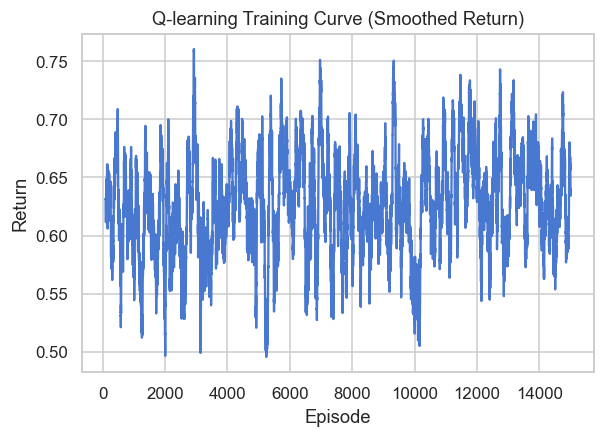

In [72]:
# Q-learning learning curve

plt.figure(figsize=(6,4))
plt.plot(pd.Series(returns).rolling(100).mean())
plt.title("Q-learning Training Curve (Smoothed Return)")
plt.xlabel("Episode")
plt.ylabel("Return")
plt.show()

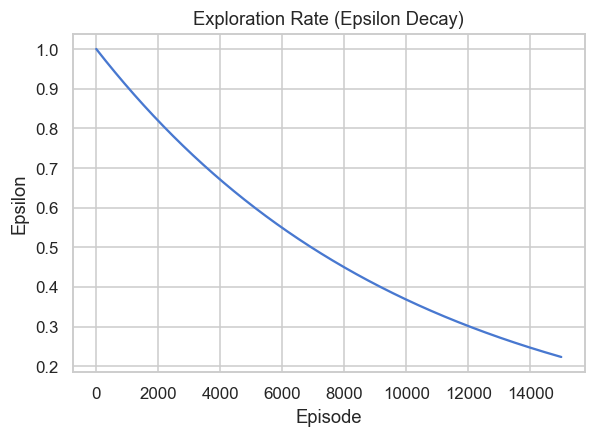

In [73]:
# Exploration vs Exploitation

plt.figure(figsize=(6,4))
plt.plot(epsilons)
plt.title("Exploration Rate (Epsilon Decay)")
plt.xlabel("Episode")
plt.ylabel("Epsilon")
plt.show()

## Final Performance Comparison

Next steps: 
- Record performance metrics: total reward per episode/ return; convergence speed; exploration vs exploitation balance.
- Provide visualizations of learning progress (reward curves, success rates).
- Perform a comparative analysis of both algorithms.

---
# Config B: RL on the Clinical ICU-Sepsis Environment

In Config A, patient state was represented as a discrete integer produced by discretising a set of clinical measurements into a small number of categories. **Config B uses the full ICU-Sepsis environment**, also built from MIMIC-III data, but with two fundamental changes that make the problem substantially harder.

**Change 1 — Continuous observations.**
The agent now receives a **47-dimensional continuous feature vector** instead of a single discrete index. This vector contains the actual normalised physiological measurements used in the original Komorowski et al. (2018) AI Clinician study, including SOFA score, heart rate, lactate, blood pressure, creatinine, and 42 other clinical variables.

With continuous observations, a tabular Q-table is no longer feasible: it would require one entry per unique float vector, making it effectively infinite. 

**Change 2 — Clinical reality wrappers.**
Config B injects three orthogonal failure modes that reflect challenges faced by real clinical AI deployments.

The first wrapper, `EpisodicNoisyObsEnv`, models episodic monitor malfunction. When active, the observations received by the agent are corrupted by noise for the entire episode, testing robustness to measurement error.

The second wrapper, `EpisodicMissingObsEnv`, models situations where lab results are unavailable for a full episode. This tests how well the agent handles partial observability.

The third wrapper, `AcuteEventEnv`, introduces rare, sudden patient deterioration events such as cardiac arrest or acute organ failure. These occur independently of any treatment decision and represent irreducible stochasticity in the environment.


Key environment properties for Config B:
- **Actions**: 25 total (5 vasopressor levels × 5 IV fluid dose levels)
- **Reward**: +1.0 at survival, 0.0 at death, plus a small treatment intensity penalty (lam = 0.02)
- **Observation**: `Box(47,)`, a normalised physiological feature vector, potentially noisy or incomplete

## Setup: Clinical ICU-Sepsis Environment


In [6]:
#  Import Clinical Reality Wrappers from wrappers.py 

from envs.wrappers import (
    EpisodicNoisyObsEnv,
    EpisodicMissingObsEnv,
    AcuteEventEnv,
    make_clinical_env,
)

print('Clinical reality wrappers imported from wrappers.py:')
print('  EpisodicNoisyObsEnv   : episodic monitor malfunction')
print('  EpisodicMissingObsEnv : episodic missing lab values')
print('  AcuteEventEnv         : rare sudden patient death')
print()
print('Required Config B env: make_clinical_env() with default parameters')


Clinical reality wrappers imported from wrappers.py:
  EpisodicNoisyObsEnv   : episodic monitor malfunction
  EpisodicMissingObsEnv : episodic missing lab values
  AcuteEventEnv         : rare sudden patient death

Required Config B env: make_clinical_env() with default parameters


In [10]:
#  Verify wrappers and random baseline on clinical environment 
import gymnasium as gym

try:
    env_clinical = make_clinical_env()
    obs, info = env_clinical.reset(seed=SEED)

    print('Clinical environment loaded successfully!')
    print(f'Observation space : {env_clinical.observation_space}')
    print(f'Action space      : {env_clinical.action_space}')
    print(f'Info keys         : {list(info.keys())}')
    print()

    # Random baseline on clinical env (1000 episodes)
    np.random.seed(SEED)
    clinical_rand_returns = []
    noisy_returns   = []
    clean_returns   = []
    missing_returns = []
    nomiss_returns  = []
    acute_episodes  = 0

    env_eval = make_clinical_env()
    for ep in range(1000):
        obs, info = env_eval.reset(seed=np.random.randint(100_000))
        total_r, done = 0.0, False
        ep_noisy   = info.get('noisy_episode', False)
        ep_missing = info.get('missing_features') is not None
        ep_acute   = False

        while not done:
            obs, r, te, tr, info = env_eval.step(env_eval.action_space.sample())
            total_r += r
            done = te or tr
            if info.get('acute_event', False):
                ep_acute = True

        clinical_rand_returns.append(total_r)
        if ep_noisy:   noisy_returns.append(total_r)
        else:          clean_returns.append(total_r)
        if ep_missing: missing_returns.append(total_r)
        else:          nomiss_returns.append(total_r)
        if ep_acute:   acute_episodes += 1

    env_eval.close()
    env_clinical.close()

    print()
    print('=== Random Baseline: Clinical Environment (1000 episodes) ===')
    print(f'Overall mean return   : {np.mean(clinical_rand_returns):.4f}')
    print(f'Overall survival rate : {np.mean(np.array(clinical_rand_returns) > 0)*100:.1f}%')
    print()

    # Store for later comparison
    clinical_rand_mean = float(np.mean(clinical_rand_returns))

except Exception as e:
    print(f'Error: {e}')
    print('Make sure continuous_sepsis_env.py is in the project root and dependencies are installed.')
    clinical_rand_mean = 0.78


make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
Clinical environment loaded successfully!
Observation space : Box(-inf, inf, (47,), float32)
Action space      : Discrete(25)
Info keys         : ['admissible_actions', 'state_vector', 'sofa_score', 'noisy_episode', 'missing_features']

make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02

=== Random Baseline: Clinical Environment (1000 episodes) ===
Overall mean return   : 0.5624
Overall survival rate : 65.6%



In [8]:
test_env = make_clinical_env()
e = test_env
while hasattr(e, 'env'):
    print(type(e).__name__)
    e = e.env
print(type(e).__name__)
test_env.close()

make_sepsis_env | lam=0.02 → intensity penalty active
make_sepsis_env | sofa_bias=5.0 → mean start SOFA: 9.02
AcuteEventEnv
EpisodicMissingObsEnv
EpisodicNoisyObsEnv
ContinuousICUSepsisEnv
